In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("cardekho.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
df.info()
print("İsnull Values:", "\n", df.isnull().sum())
display(df.head())
display(df.describe())

Shape:  (15411, 14)
Columns:  Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [3]:
df = df.drop("Unnamed: 0", axis=1)
print(df.columns)

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')


In [4]:
print("Number of duplicates: ", df.duplicated().sum())

Number of duplicates:  167


In [5]:
df = df.drop_duplicates(keep="first", ignore_index=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["seats"].value_counts()

seats
5    12767
7     1902
8      310
6      125
4       76
9       55
2        7
0        2
Name: count, dtype: int64

In [8]:
df.loc[df["seats"] == 0, "seats"] = 5

In [9]:
df["seats"].value_counts()

seats
5    12769
7     1902
8      310
6      125
4       76
9       55
2        7
Name: count, dtype: int64

In [10]:
pd.set_option("display.float_format", "{:.2f}".format)

In [11]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00
mean,6.04,55639.58,19.70,1486.17,100.61,5.33,774701.45
std,3.02,51766.30,4.17,520.42,42.92,0.81,894676.08
min,0.00,100.00,4.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,559000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [12]:
numerical = [i for i in df.columns if df[i].dtype != "O"]
categorical = [j for j in df.columns if df[j].dtype == "O"]
print(len(numerical))
print(len(categorical))

7
6


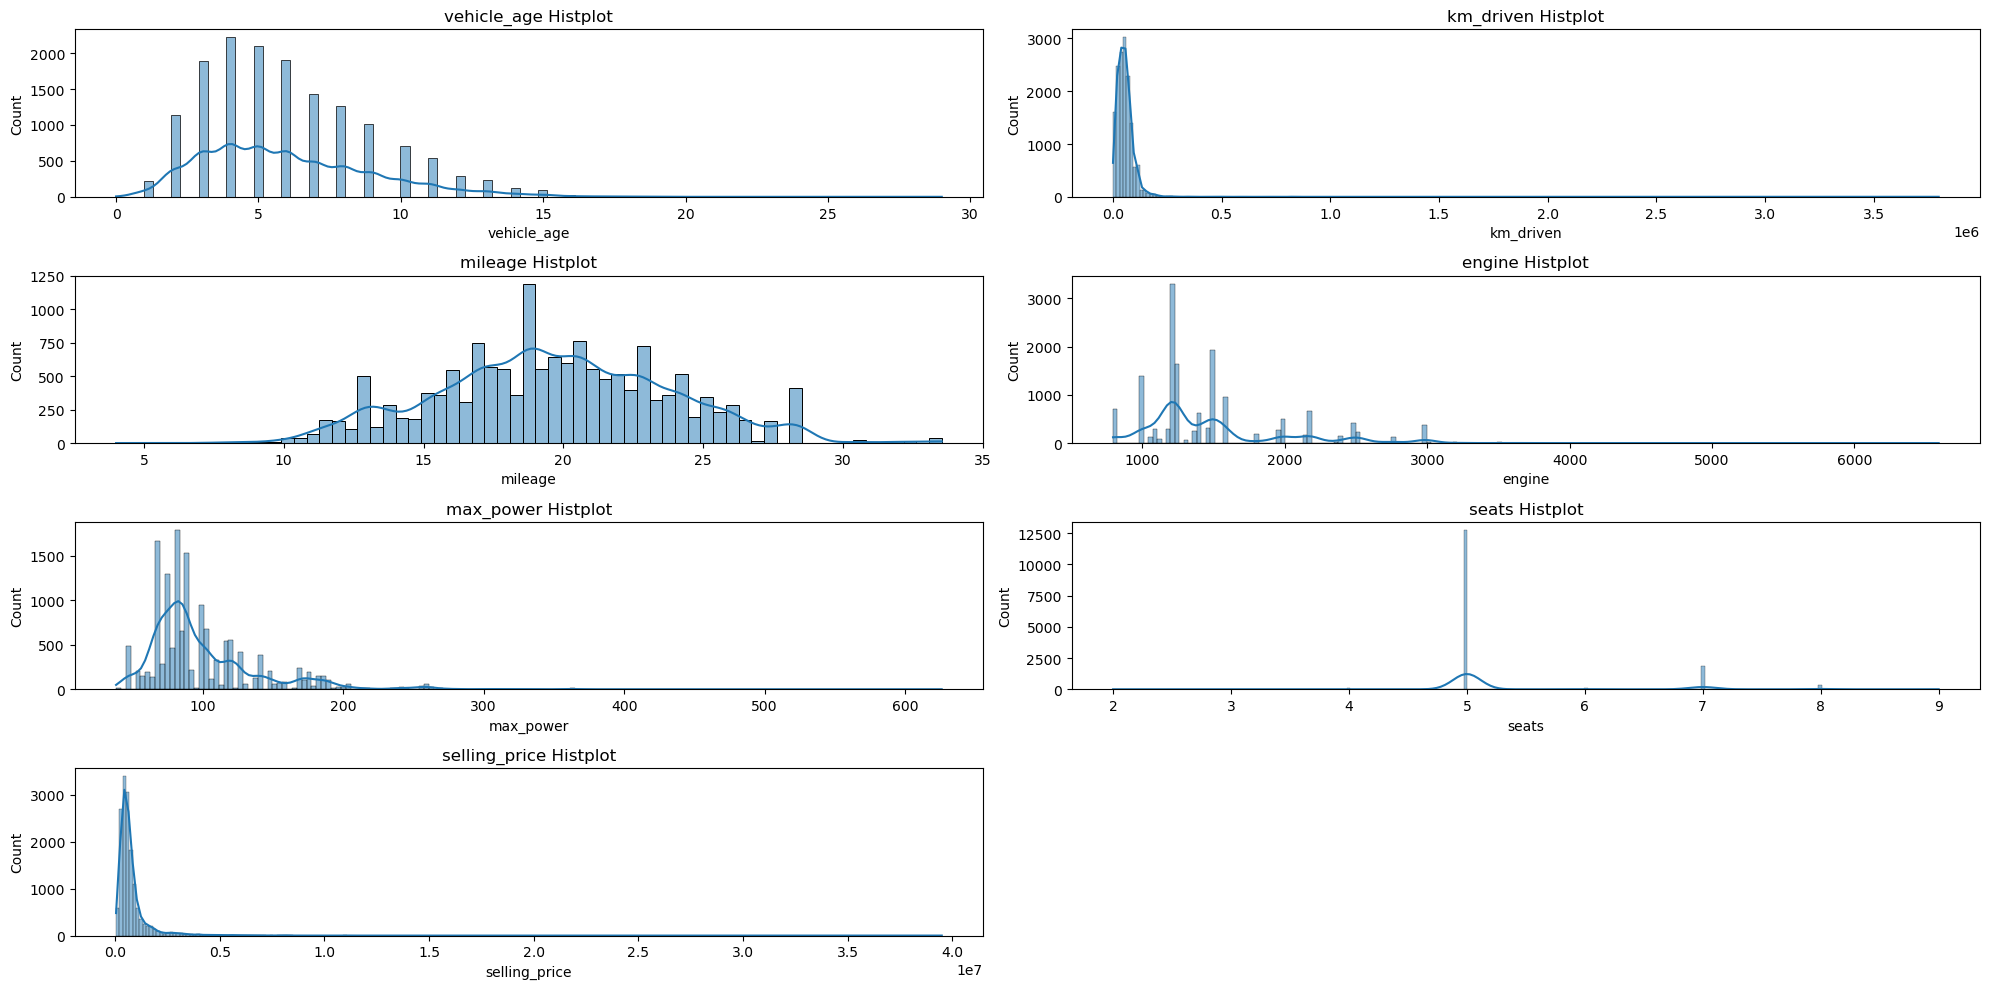

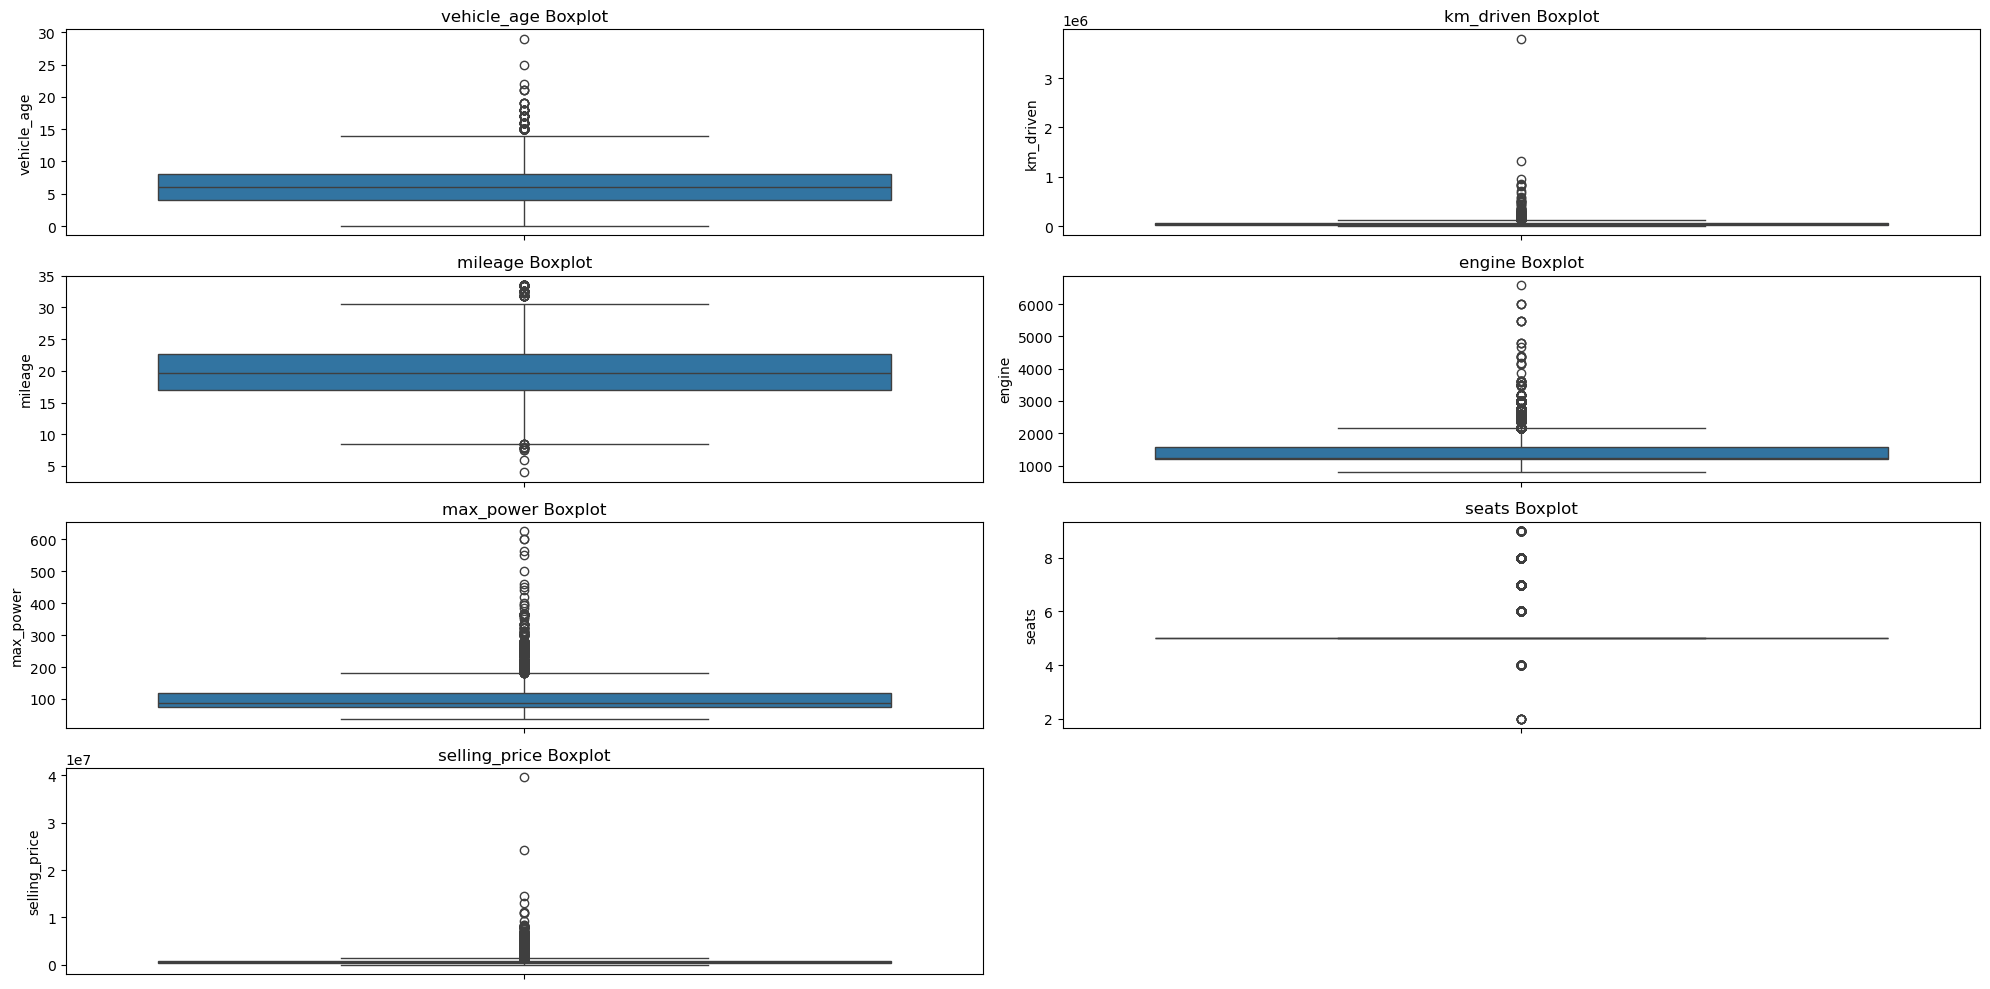

In [13]:
def plot_numerics(data, columns):
    fig, ax = plt.subplots(4,2, figsize=(20,10))
    ax = ax.flatten()

    for i, col in enumerate(columns):
        sns.histplot(
            x = col,
            data = data,
            ax = ax[i],
            kde = True
        )
        ax[i].set_title(f"{col} Histplot")

    for i in range(i+1, len(ax)):
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

    fig1, ax1 = plt.subplots(4,2, figsize=(20,10))
    ax1 = ax1.flatten()
    
    for j, col in enumerate(columns):
        sns.boxplot(
            y = col,
            data = data,
            ax = ax1[j]
        )
        ax1[j].set_title(f"{col} Boxplot")

    for j in range(j+1, len(ax1)):
        ax1[j].axis("off")
    
    plt.tight_layout()
    plt.show()

plot_numerics(df, numerical)

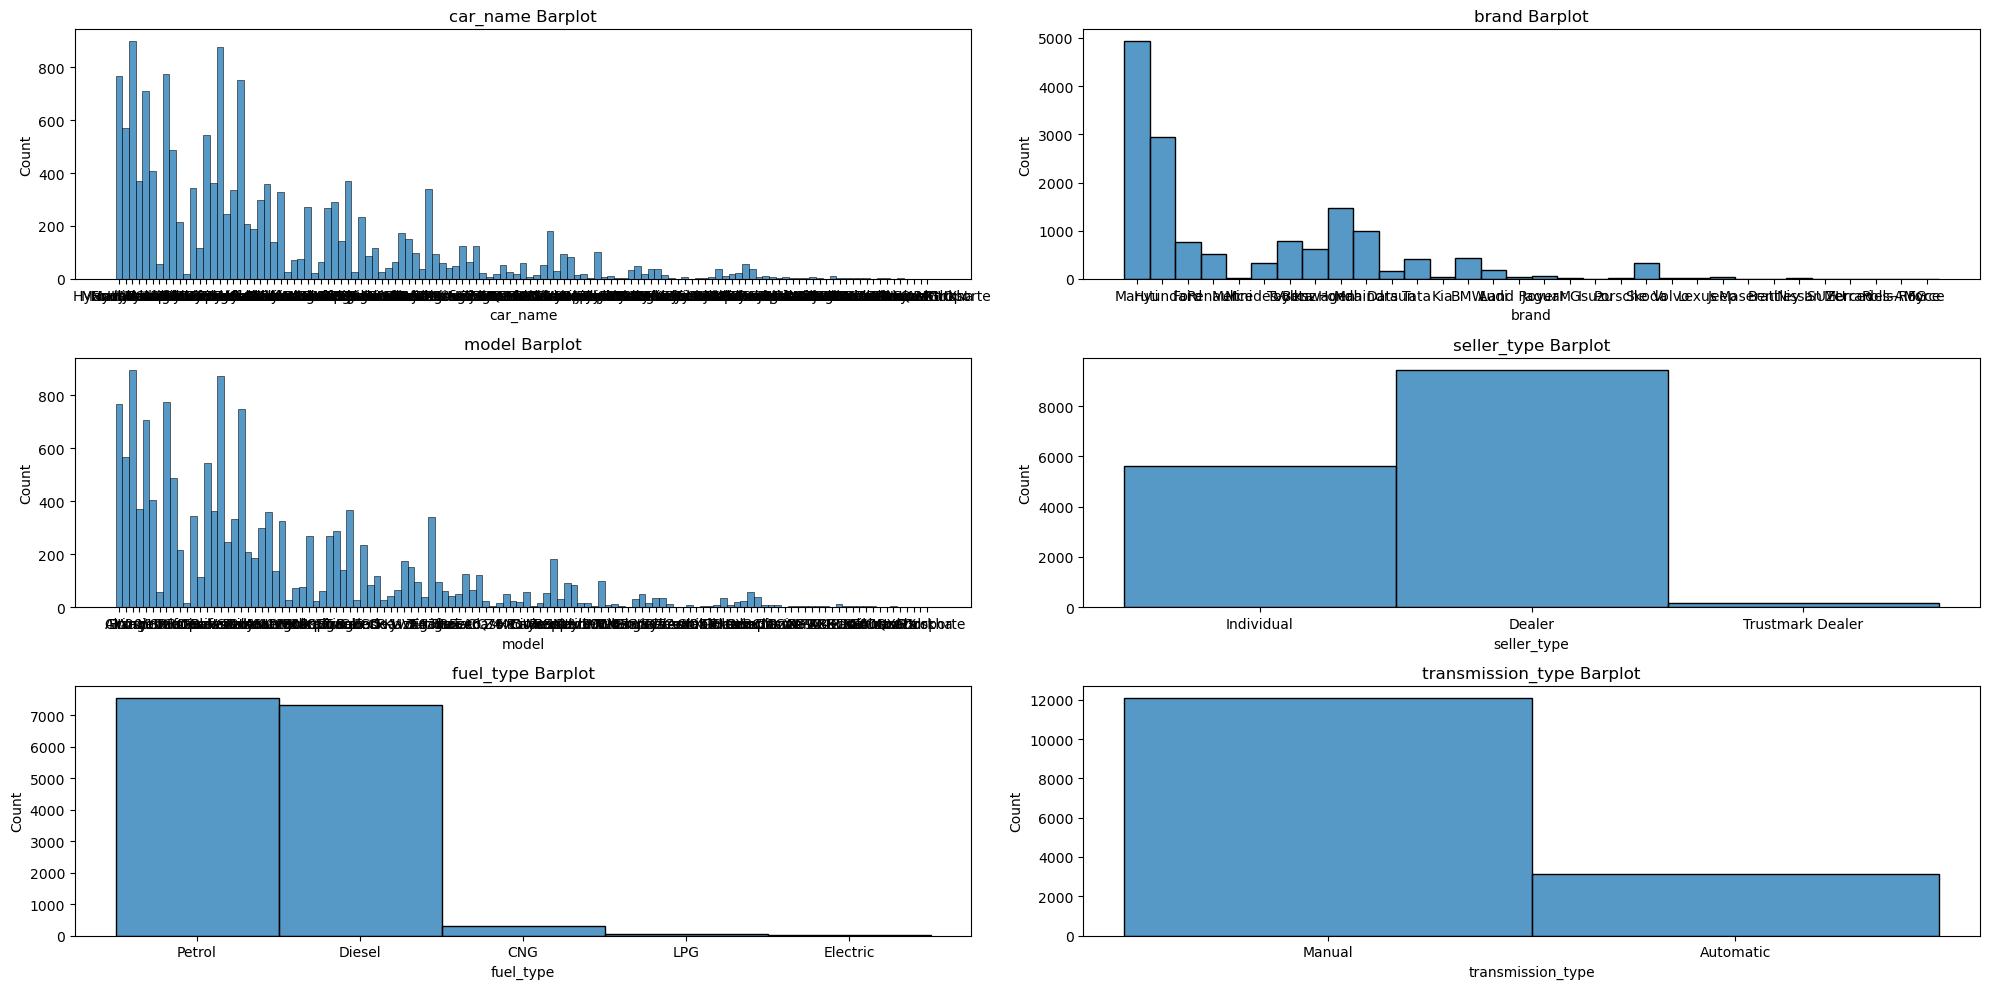

In [14]:
def plot_categorics(data, columns):

    fig, ax = plt.subplots(3, 2, figsize=(20,10))
    ax = ax.flatten()

    for i, col in enumerate(columns):
        sns.histplot(
            x = col,
            data = data,
            ax = ax[i],
        )
        ax[i].set_title(f"{col} Barplot")
    
    plt.tight_layout()
    plt.show()

plot_categorics(df, categorical)

In [15]:
for k in ["car_name", "brand", "model"]:
    print(f"Values in {k}")
    print(df[k].value_counts())
    print("Number of Unique Values: ", len(df[k].unique()))
    print("--------------------------")

Values in car_name
car_name
Hyundai i20           898
Maruti Swift Dzire    875
Maruti Swift          774
Maruti Alto           768
Honda City            750
                     ... 
Mercedes-AMG C          1
Tata Altroz             1
Ferrari GTC4Lusso       1
Hyundai Aura            1
Force Gurkha            1
Name: count, Length: 121, dtype: int64
Number of Unique Values:  121
--------------------------
Values in brand
brand
Maruti           4933
Hyundai          2952
Honda            1476
Mahindra          999
Toyota            789
Ford              776
Volkswagen        614
Renault           527
BMW               436
Tata              421
Skoda             333
Mercedes-Benz     332
Audi              190
Datsun            170
Jaguar             58
Land Rover         50
Jeep               41
Kia                32
Porsche            21
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus               9
Isuzu               7
Bentley           

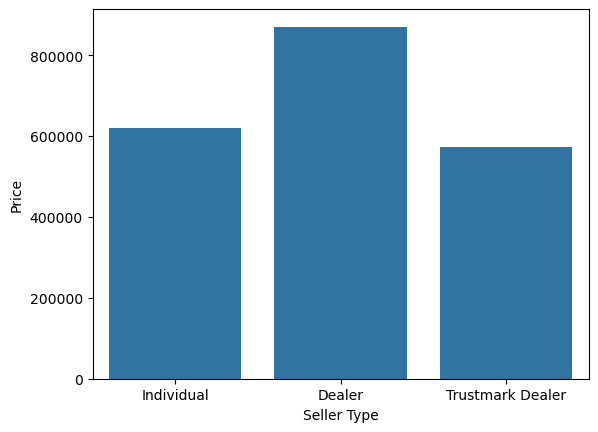

In [16]:
sns.barplot(x="seller_type", y="selling_price", data=df, estimator="mean", errorbar=None)
plt.xlabel("Seller Type")
plt.ylabel("Price")
plt.show()

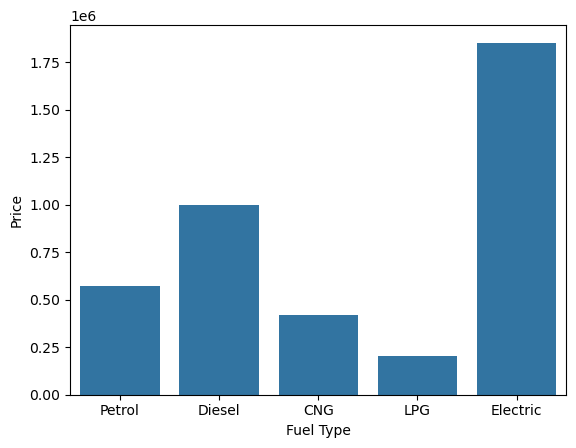

In [17]:
sns.barplot(x="fuel_type", y="selling_price", data=df, estimator="mean", errorbar=None)
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()

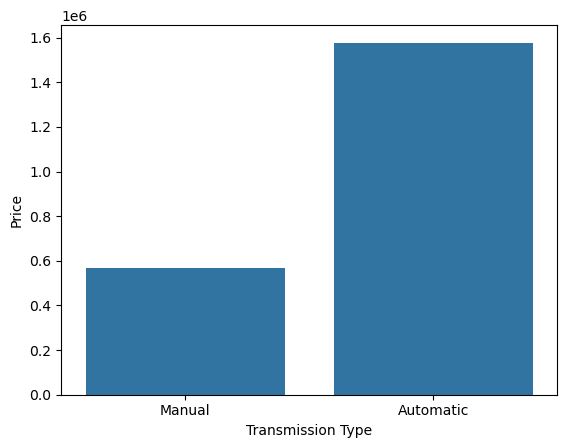

In [18]:
sns.barplot(x="transmission_type", y="selling_price", data=df, estimator="mean", errorbar=None)
plt.xlabel("Transmission Type")
plt.ylabel("Price")
plt.show()

In [19]:
numerical

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

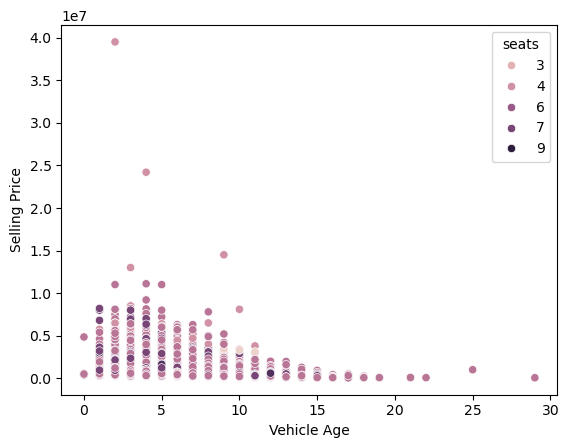

In [20]:
sns.scatterplot(x="vehicle_age", y="selling_price", hue="seats", data=df)
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.show()

In [21]:
df = df[df["selling_price"] < 1500000]

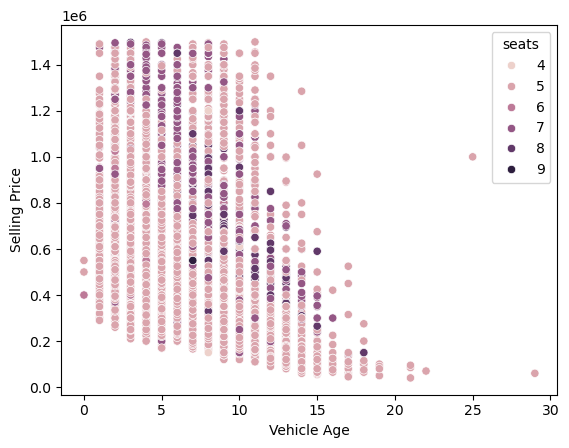

In [22]:
sns.scatterplot(x="vehicle_age", y="selling_price", hue="seats", data=df)
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.show()

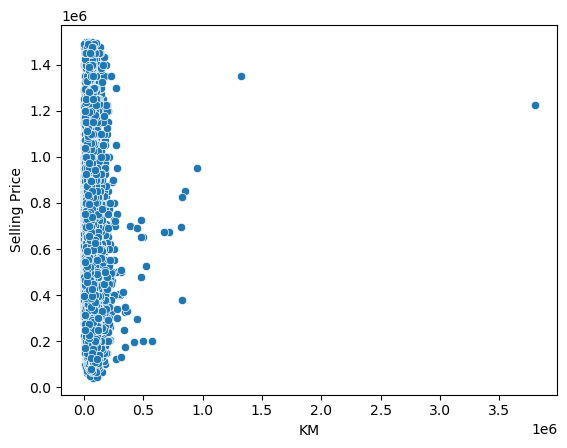

In [23]:
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.xlabel("KM")
plt.ylabel("Selling Price")
plt.show()

In [24]:
df = df[df["km_driven"] < 1000000]

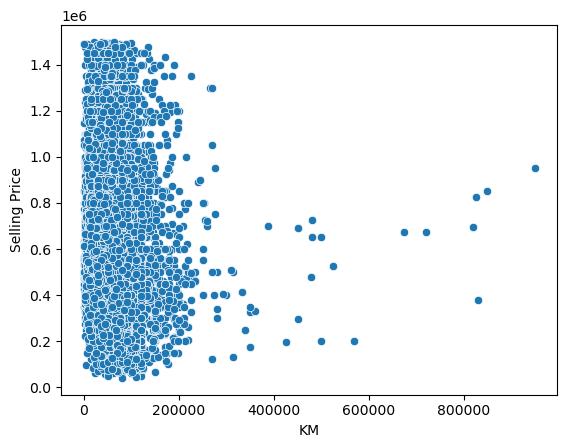

In [25]:
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.xlabel("KM")
plt.ylabel("Selling Price")
plt.show()

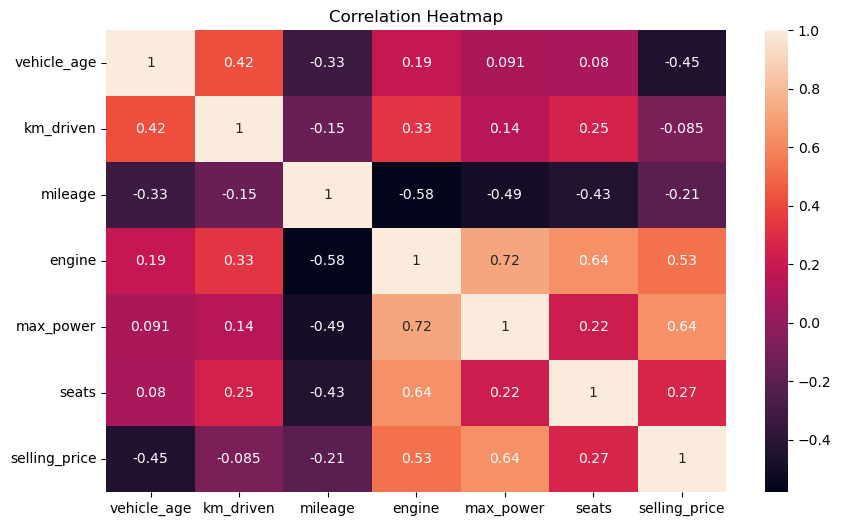

In [26]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13890 entries, 0 to 15243
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           13890 non-null  object 
 1   brand              13890 non-null  object 
 2   model              13890 non-null  object 
 3   vehicle_age        13890 non-null  int64  
 4   km_driven          13890 non-null  int64  
 5   seller_type        13890 non-null  object 
 6   fuel_type          13890 non-null  object 
 7   transmission_type  13890 non-null  object 
 8   mileage            13890 non-null  float64
 9   engine             13890 non-null  int64  
 10  max_power          13890 non-null  float64
 11  seats              13890 non-null  int64  
 12  selling_price      13890 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [28]:
for i  in ["seller_type", "fuel_type", "transmission_type"]:
    print("n_uniques in {}:".format(i), df[i].nunique())

n_uniques in seller_type: 3
n_uniques in fuel_type: 4
n_uniques in transmission_type: 2


In [29]:
for i  in ["car_name", "brand", "model"]:
    print("n_uniques in {}:".format(i), df[i].nunique())

n_uniques in car_name: 93
n_uniques in brand: 24
n_uniques in model: 93


In [30]:
one_hot_columns = ["seller_type", "fuel_type", "transmission_type"]
freq_columns = ["car_name", "brand", "model"]

In [31]:
from sklearn.model_selection import train_test_split
X = df.drop("selling_price", axis=1)
y = df["selling_price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [32]:
for col in freq_columns:
    freqs = X_train[col].value_counts() / len(X_train)
    X_train[col + "_freq"] = X_train[col].map(freqs)
    X_test[col + "_freq"] = X_test[col].map(freqs)
    mean_freq = freqs.mean()
    X_test[col + "_freq"] = X_test[col + "_freq"].fillna(mean_freq)

In [33]:
X_train = X_train.drop(["car_name", "brand", "model"], axis=1)
X_test = X_test.drop(["car_name", "brand", "model"], axis=1)

In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
encoder = OneHotEncoder(handle_unknown="ignore", drop="first")
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, one_hot_columns)
    ],
    remainder="passthrough"
)
X_train_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns = preprocessor.get_feature_names_out(),
    index = X_train.index
)
X_test_encoded = pd.DataFrame(
    preprocessor.transform(X_test),
    columns = preprocessor.get_feature_names_out(),
    index = X_test.index
)

In [35]:
X_train_encoded.head()

,cat__seller_type_Individual,cat__seller_type_Trustmark Dealer,cat__fuel_type_Diesel,cat__fuel_type_LPG,cat__fuel_type_Petrol,cat__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
1857,1.00,0.00,0.00,0.00,1.00,1.00,8.00,60000.00,20.51,998.00,67.04,5.00,0.05,0.35,0.05
3362,1.00,0.00,0.00,0.00,1.00,1.00,9.00,24750.00,20.36,1197.00,78.90,5.00,0.03,0.21,0.03
6280,0.00,0.00,0.00,0.00,1.00,1.00,10.00,45452.00,15.60,1196.00,70.00,5.00,0.02,0.05,0.02
14492,1.00,0.00,1.00,0.00,0.00,1.00,9.00,70000.00,20.00,1399.00,68.00,5.00,0.02,0.05,0.02
6147,1.00,0.00,0.00,0.00,1.00,1.00,3.00,25000.00,20.51,998.00,67.04,5.00,0.05,0.35,0.05


In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [136]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_and_evaluate(models, X_train, X_test, y_train, y_test):
    
    def calculate_metrics(true, predictions):
        mse = mean_squared_error(true, predictions)
        mae = mean_absolute_error(true, predictions)
        r2 = r2_score(true, predictions)
        return (mse, mae, r2)

    model_obj = list(models.values())
    model_names = list(models.keys())

    results = []
    for name, model in zip(model_names, model_obj):
        model.fit(X_train, y_train)
        y_pred_training = model.predict(X_train)
        y_pred_testing = model.predict(X_test)
        train_mse, train_mae, train_r2 = calculate_metrics(y_train, y_pred_training)
        test_mse, test_mae, test_r2 = calculate_metrics(y_test, y_pred_testing)
        overfit_grap = abs(train_r2 - test_r2)
        result = {
            "model_name": name,
            "train_mse": train_mse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "test_mse": test_mse,
            "test_mae": test_mae,
            "test_r2": test_r2,
            "overfit_grap": overfit_grap
        }
        results.append(result)
    data = pd.DataFrame(results)
    return data

In [137]:
models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(),
    "lasso": Lasso(),
    "svr": SVR(),
    "knn_regressor": KNeighborsRegressor(),
    "decision_tree_regressor": DecisionTreeRegressor(),
    "random_forest_regressor": RandomForestRegressor(),
    "adaboost_regressor": AdaBoostRegressor()
}
results = train_and_evaluate(models, X_train_scaled, X_test_scaled, y_train, y_test)

In [138]:
results

,model_name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_grap
0,linear_regression,19702524604.17,103912.55,0.75,19212341893.49,103025.32,0.74,0.01
1,ridge,19702525491.09,103912.94,0.75,19212097800.41,103025.05,0.74,0.01
2,lasso,19702524628.64,103912.70,0.75,19212328619.97,103025.38,0.74,0.01
3,svr,82557388062.73,219346.71,-0.03,76958308436.58,212073.84,-0.03,0.00
4,knn_regressor,7325237946.36,59530.27,0.91,10762339966.40,73097.48,0.86,0.05
5,decision_tree_regressor,314008642.74,4682.55,1.00,15257725320.17,85524.71,0.80,0.20
6,random_forest_regressor,1550840502.60,27287.21,0.98,8897266152.38,67129.42,0.88,0.10
7,adaboost_regressor,21098115112.89,117830.86,0.74,21354637134.65,118403.62,0.71,0.02


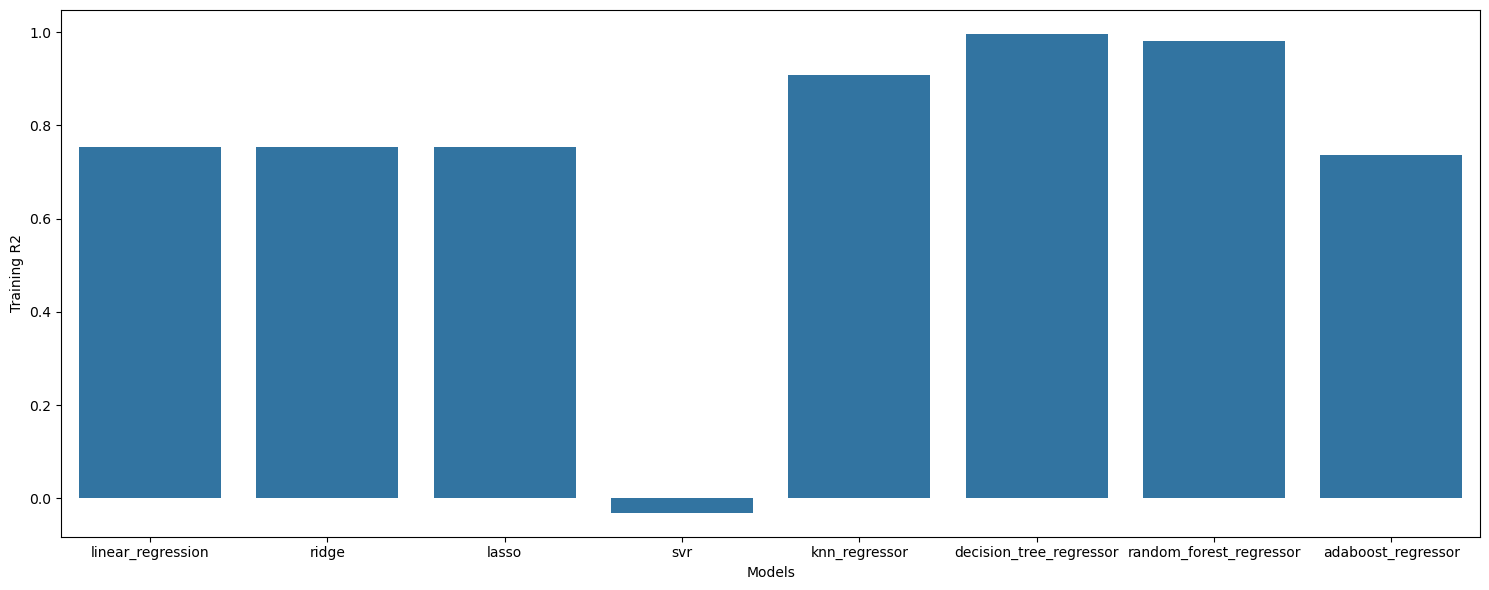

In [145]:
plt.figure(figsize=(15,6))
sns.barplot(x="model_name", y="train_r2", data=results)
plt.xlabel("Models")
plt.ylabel("Training R2")
plt.tight_layout()
plt.show()

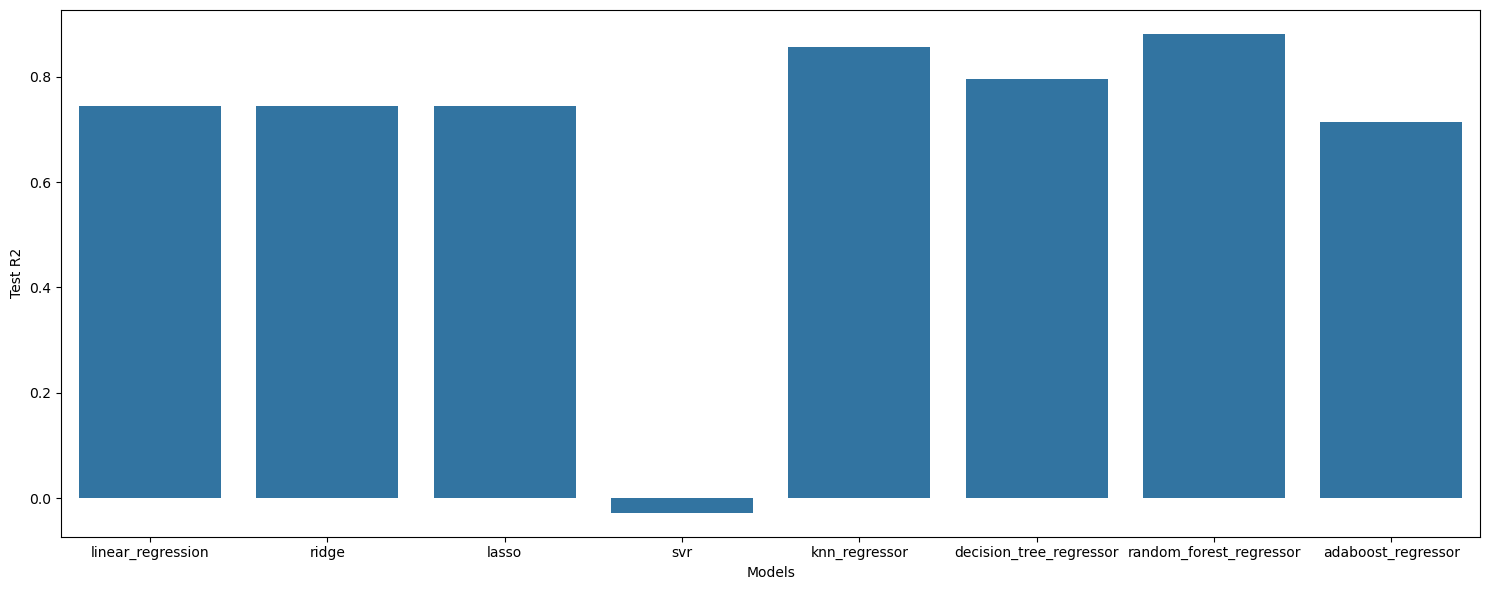

In [146]:
plt.figure(figsize=(15,6))
sns.barplot(x="model_name", y="test_r2", data=results)
plt.xlabel("Models")
plt.ylabel("Test R2")
plt.tight_layout()
plt.show()

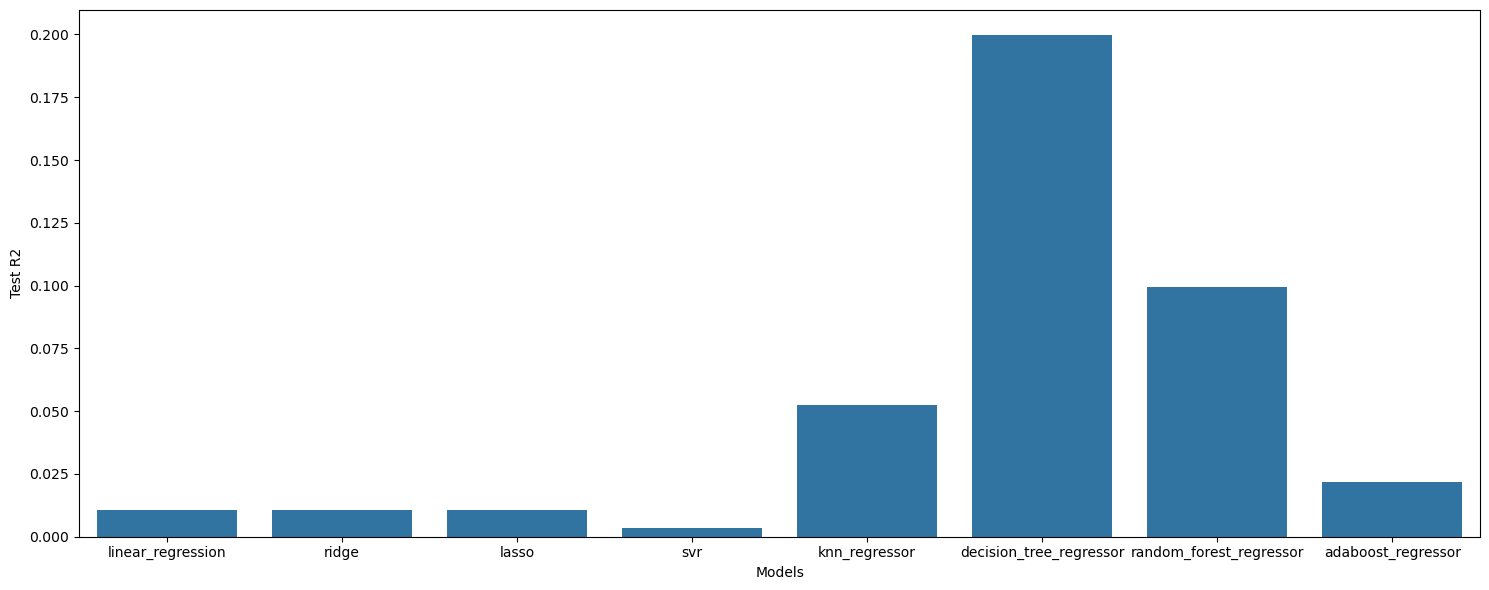

In [147]:
plt.figure(figsize=(15,6))
sns.barplot(x="model_name", y="overfit_grap", data=results)
plt.xlabel("Models")
plt.ylabel("Test R2")
plt.tight_layout()
plt.show()

In [149]:
tuning_models = {
    "knn_regressor": KNeighborsRegressor(n_neighbors=6),
    "decision_tree_regressor": DecisionTreeRegressor(max_depth=10, max_features="sqrt", min_samples_leaf=2, min_samples_split=5, random_state=15),
    "random_forest_regressor": RandomForestRegressor(max_depth=10, max_features="sqrt", min_samples_leaf=2, min_samples_split=5, n_estimators=150, random_state=15),
    "adaboost_regressor": AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6),learning_rate=5, loss="exponential", n_estimators=150, random_state=15)
}
tuning_result = train_and_evaluate(tuning_models, X_train_scaled, X_test_scaled, y_train, y_test)

In [150]:
tuning_result

,model_name,train_mse,train_mae,train_r2,test_mse,test_mae,test_r2,overfit_grap
0,knn_regressor,7830962858.55,61744.10,0.90,10535483901.29,72544.64,0.86,0.04
1,decision_tree_regressor,11669835710.77,77381.98,0.85,14543870833.43,86926.28,0.81,0.05
2,random_forest_regressor,7341277796.11,63090.30,0.91,9105351381.47,69446.53,0.88,0.03
3,adaboost_regressor,10014728524.41,82336.33,0.87,11654336878.62,85294.84,0.84,0.03


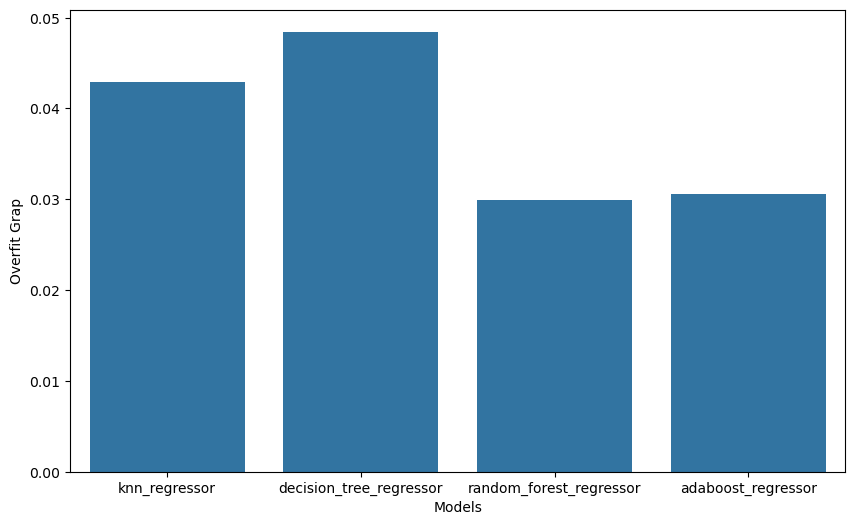

In [152]:
plt.figure(figsize=(10,6))
sns.barplot(x="model_name", y="overfit_grap", data=tuning_result)
plt.xlabel("Models")
plt.ylabel("Overfit Grap")
plt.show()